# Raw-to-result tutorial 1 — subQ Rab8a

This notebook starts from the downloaded **raw sparse RNA and guide H5 files**.
It does not read any frozen PerturbRadius result table. We infer a conservative
malignant-like label from marker modules, call high-confidence Rab8a source
components, measure distance from the guide-positive source boundary, and plot
both entire sections and clone-local response fields.

Scientific question: do malignant bins near Rab8a source components show a
hypoxic, IFN-low state? This is a descriptive spatial association. A propagation
radius is not reported because one guide dominates and NTC clone support is
insufficient.

In [1]:
from pathlib import Path
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

REPO = Path.cwd()
if not (REPO / "pyproject.toml").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src"))
DATA_ROOT = Path(os.environ.get("PERTURBRADIUS_DATA_ROOT", "/home/dataset-local/hulei/SpDiff/data"))
RAW = DATA_ROOT / "SPAC" / "processed"

import perturbradius as pr
plt.rcParams.update({"font.size": 13, "axes.grid": False, "lines.linewidth": 1.7,
                     "figure.dpi": 120, "font.family": "DejaVu Sans"})
samples = ["subQ-2", "subQ-4", "subQ-5"]
for sample in samples:
    assert (RAW / "Transcriptome" / sample / "filtered_gene_bc_matrix.h5").exists()
    assert (RAW / "Perturbation" / sample / "filtered_guide_bc_matrix.h5").exists()
print("Raw root:", RAW)

Raw root: /home/dataset-local/hulei/SpDiff/data/SPAC/processed


In [2]:
# Raw-file audit: dimensions are read from H5 metadata, not a derived table.
rna_path = RAW / "Transcriptome" / "subQ-2" / "filtered_gene_bc_matrix.h5"
guide_path = RAW / "Perturbation" / "subQ-2" / "filtered_guide_bc_matrix.h5"
display(pr.h5_schema(rna_path).query("dataset in ['X/data','X/indptr','obs/_index','var/_index','obsm/spatial']"))
display(pr.h5_schema(guide_path).query("dataset in ['X/data','X/indptr','obs/_index','var/_index','obsm/spatial']"))

,dataset,shape,dtype
0,X/data,277576255,float32
2,X/indptr,615252,int32
3,obs/_index,615251,object
7,obsm/spatial,615251 × 3,float64
8,var/_index,19059,object


,dataset,shape,dtype
0,X/data,220955,float32
2,X/indptr,615252,int32
3,obs/_index,615251,object
7,obsm/spatial,615251 × 3,float64
8,var/_index,1520,object


In [3]:
# Stream only the marker genes needed for lineage and response scores.
modules = {
    "malignant": ["Epcam", "Krt8", "Krt18", "Krt19", "Krt20", "Krt7"],
    "cd8_like": ["Cd3d", "Cd3e", "Cd247", "Cd8a", "Cd8b1", "Trac"],
    "macrophage": ["Adgre1", "Csf1r", "Cd68", "Lyz2", "Fcgr1"],
    "fibroblast": ["Col1a1", "Col1a2", "Dcn", "Lum", "Pdgfra"],
    "endothelial": ["Pecam1", "Vwf", "Kdr", "Emcn", "Eng"],
    "hypoxia": ["Hif1a", "Vegfa", "Slc2a1", "Ldha", "Pdk1"],
    "ifn_response": ["Stat1", "Irf1", "Isg15", "Ifit1", "Ifit3", "Cxcl10"],
}
lineages = ["malignant", "cd8_like", "macrophage", "fibroblast", "endothelial"]
parts, guide_qc, marker_qc = [], [], []
for sample in samples:
    rna = RAW / "Transcriptome" / sample / "filtered_gene_bc_matrix.h5"
    guide = RAW / "Perturbation" / sample / "filtered_guide_bc_matrix.h5"
    axes = pr.read_h5_axes(rna)
    calls = pr.read_sparse_guide_calls(guide)
    scores, present = pr.stream_module_scores(rna, modules, chunk_rows=12_000)
    scores = pr.marker_lineage(scores, lineages, threshold=0.50)
    frame = axes.merge(calls, on="barcode", validate="one_to_one").merge(
        scores, on="barcode", validate="one_to_one")
    frame["section"] = sample
    frame["x_um"], frame["y_um"] = frame.array_col * 8.0, frame.array_row * 8.0
    frame["target_gene"] = frame.target_gene.fillna("")
    frame["guide"] = frame.top_guide.fillna("")
    frame["is_ntc"] = frame.is_ntc.astype(bool)
    frame["is_source"] = ((frame.guide_total >= 2) & (frame.top_fraction >= 0.70)
                          & frame.inferred_lineage.eq("malignant"))
    frame["response"] = frame.score_hypoxia.where(frame.inferred_lineage.eq("malignant"))
    frame["malignant_hypoxia"] = frame.score_hypoxia.where(frame.inferred_lineage.eq("malignant"))
    frame["malignant_ifn"] = frame.score_ifn_response.where(frame.inferred_lineage.eq("malignant"))
    parts.append(frame)
    rab = frame.is_source & frame.target_gene.eq("Rab8a")
    guide_qc.append({"section": sample, "bins": len(frame), "malignant_like": int(frame.inferred_lineage.eq('malignant').sum()),
                     "Rab8a_source_bins": int(rab.sum()),
                     "Rab8a_guides": int(frame.loc[rab, 'guide'].nunique())})
    marker_qc.append({"section": sample, **{name: len(genes) for name, genes in present.items()}})

data = pr.validate_data(pd.concat(parts, ignore_index=True))
display(pd.DataFrame(guide_qc))
display(pd.DataFrame(marker_qc).set_index("section"))

,section,bins,malignant_like,Rab8a_source_bins,Rab8a_guides
0,subQ-2,615251,69630,704,2
1,subQ-4,632143,66599,1531,2
2,subQ-5,556815,60825,408,2


,malignant,cd8_like,macrophage,fibroblast,endothelial,hypoxia,ifn_response
section,,,,,,,
subQ-2,6,6,5,5,5,5,6
subQ-4,6,6,5,5,5,5,6
subQ-5,6,6,5,5,5,5,6


In [4]:
# Source components are called independently within section, target and guide.
components = pr.call_components(data, perturbation="Rab8a", eps_um=24,
                                min_samples=10, min_source_bins=20)
rings = pr.build_distance_rings(data, components,
                                ring_edges=(0, 20, 40, 80, 120, 200),
                                bin_size_um=8, exclude_all_sources=True)
source = components.membership.merge(data[["_row_id", "section", "x_um", "y_um"]], on="_row_id")
display(components.summary)
print(f"Called {len(components.summary)} components in {components.summary.section.nunique()} sections; "
      f"{len(rings):,} target bins fall within 200 µm of their nearest component.")

,component_id,section,target_gene,guide,is_ntc,n_source_bins,centroid_x_um,centroid_y_um
0,C0001,subQ-2,Rab8a,sgRab8a_1,False,28,1114.857143,5296.571429
1,C0002,subQ-2,Rab8a,sgRab8a_1,False,23,1160.347826,5510.608696
2,C0003,subQ-4,Rab8a,sgRab8a_1,False,21,5587.047619,4806.857143
3,C0004,subQ-4,Rab8a,sgRab8a_1,False,100,5441.760000,4793.360000
4,C0005,subQ-4,Rab8a,sgRab8a_1,False,60,5064.800000,4737.200000
5,C0006,subQ-4,Rab8a,sgRab8a_1,False,28,5544.857143,4625.428571
6,C0007,subQ-4,Rab8a,sgRab8a_1,False,102,5284.862745,4671.764706
7,C0008,subQ-4,Rab8a,sgRab8a_1,False,34,5447.058824,5005.647059
8,C0009,subQ-4,Rab8a,sgRab8a_1,False,20,5156.400000,4825.200000
9,C0010,subQ-4,Rab8a,sgRab8a_1,False,23,4907.130435,4678.956522


Called 11 components in 3 sections; 15,882 target bins fall within 200 µm of their nearest component.


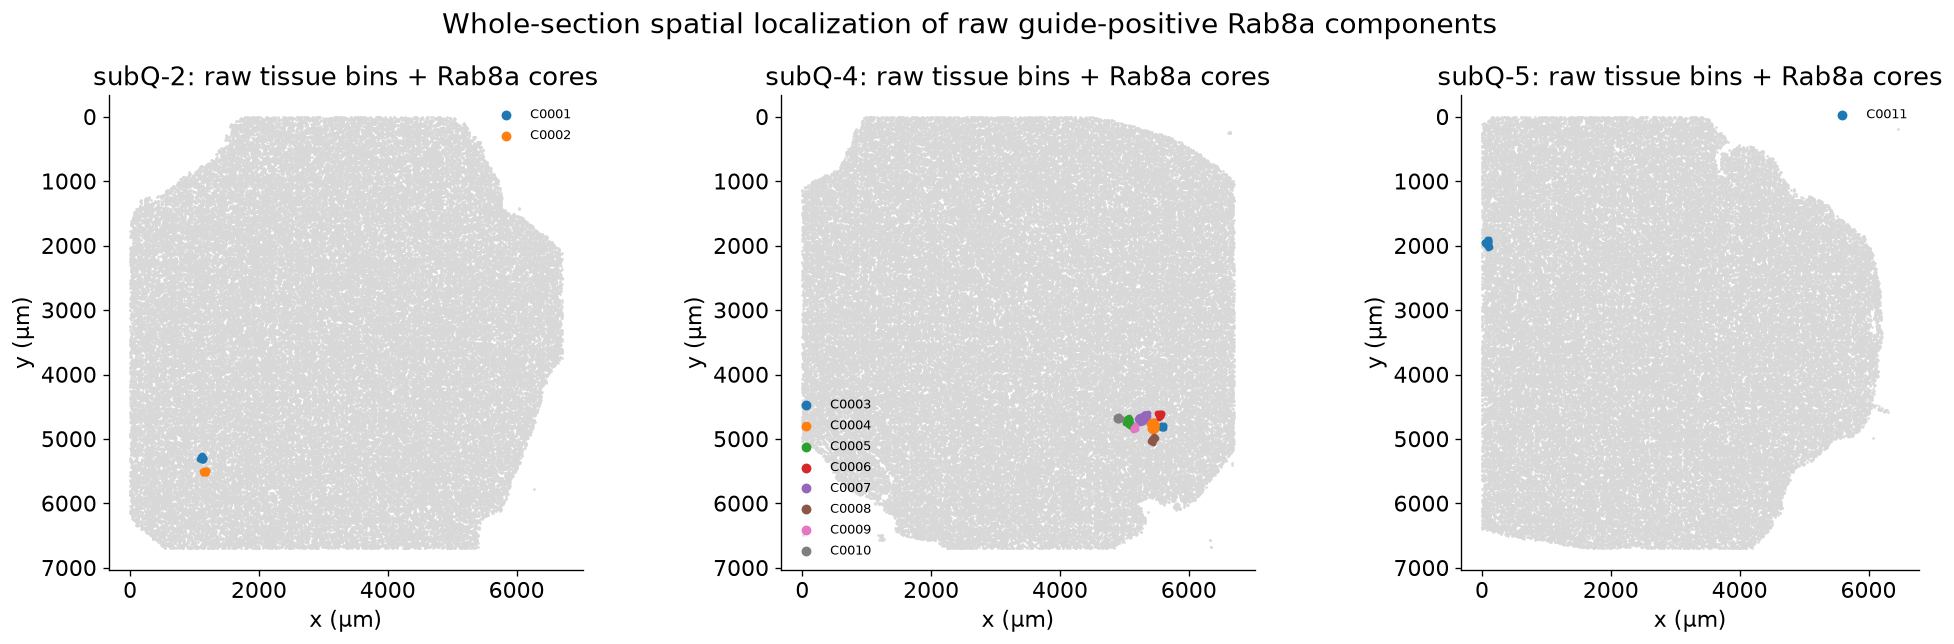

In [5]:
# Whole-section view. Background bins are downsampled only for drawing.
fig, axes = plt.subplots(1, 3, figsize=(17, 5.4))
palette = plt.get_cmap("tab10")
for ax, sample in zip(axes, samples):
    tissue = data[data.section.eq(sample)].iloc[::8]
    ax.scatter(tissue.x_um, tissue.y_um, s=.35, color="#D8D8D8", rasterized=True)
    for j, (cid, group) in enumerate(source[source.section.eq(sample)].groupby("component_id")):
        ax.scatter(group.x_um, group.y_um, s=6, color=palette(j % 10), label=cid, rasterized=True)
    ax.set_title(f"{sample}: raw tissue bins + Rab8a cores")
    ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)"); ax.set_aspect("equal"); ax.invert_yaxis()
    ax.spines[["top", "right"]].set_visible(False)
    if source.section.eq(sample).any(): ax.legend(frameon=False, fontsize=8, markerscale=2)
fig.suptitle("Whole-section spatial localization of raw guide-positive Rab8a components", fontsize=17)
fig.tight_layout(); plt.show()

In [6]:
# Component-level, far-centred response profiles.
target = rings[rings.inferred_lineage.eq("malignant")].copy()
responses = {"malignant_hypoxia": "Hypoxia program", "malignant_ifn": "IFN-response program"}
curves = []
for column, label in responses.items():
    table = target.groupby(["component_id", "section", "ring_index", "ring"], as_index=False)[column].mean()
    far = table[table.ring_index.eq(4)][["component_id", column]].rename(columns={column: "far"})
    table = table.merge(far, on="component_id", validate="many_to_one")
    table["delta"] = table[column] - table.far
    table["response_name"] = label
    curves.append(table)
curves = pd.concat(curves, ignore_index=True)
near_far = (curves[curves.ring_index.isin([0, 1])]
            .groupby(["component_id", "section", "response_name"], as_index=False).delta.mean())
display(near_far.pivot(index=["component_id", "section"], columns="response_name", values="delta").round(3))

,response_name,Hypoxia program,IFN-response program
component_id,section,,
C0001,subQ-2,0.128,-0.077
C0002,subQ-2,0.061,-0.034
C0003,subQ-4,0.026,0.143
C0004,subQ-4,0.054,0.249
C0005,subQ-4,-0.009,-0.029
C0006,subQ-4,0.064,-0.372
C0007,subQ-4,0.122,0.028
C0008,subQ-4,0.297,-0.104
C0009,subQ-4,0.088,-0.156


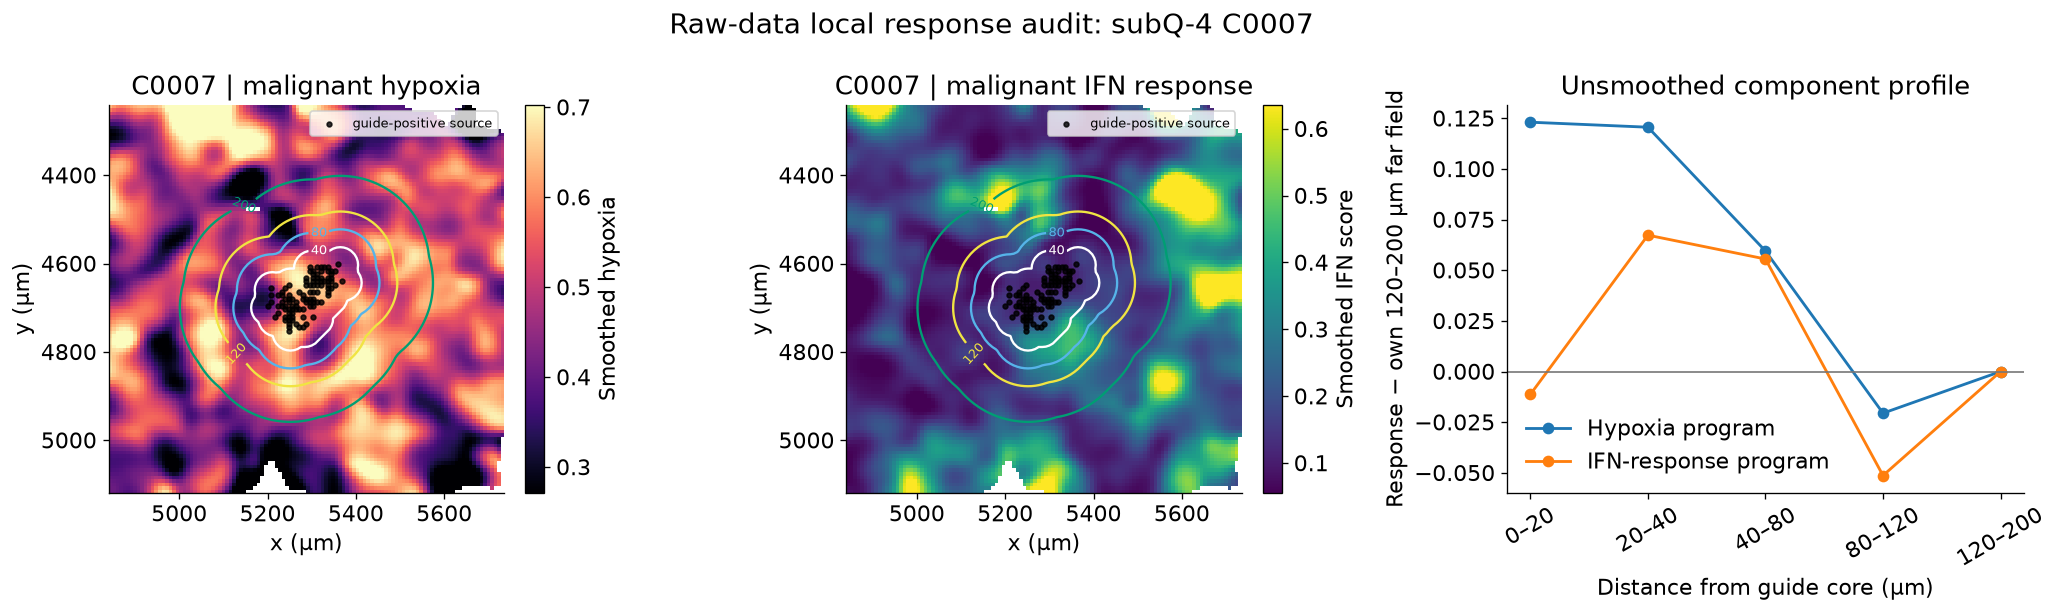

In [7]:
# Local spatial maps like the project Rab8a heatmap: black source core, physical contours,
# and an unsmoothed radial curve. Choose the largest raw component.
representative = components.summary.sort_values("n_source_bins", ascending=False).iloc[0]
cid, section = representative.component_id, representative.section
local_data = data[data.section.eq(section)]
local_source = source[source.component_id.eq(cid)]
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
pr.plot_local_response(local_data, local_source, response_col="malignant_hypoxia",
                       resolution=8, pad=360, sigma_bins=3, contour_levels=(40,80,120,200),
                       ax=axes[0], title=f"{cid} | malignant hypoxia", cbar_label="Smoothed hypoxia")
pr.plot_local_response(local_data, local_source, response_col="malignant_ifn",
                       resolution=8, pad=360, sigma_bins=3, contour_levels=(40,80,120,200),
                       ax=axes[1], title=f"{cid} | malignant IFN response", cbar_label="Smoothed IFN score",
                       cmap="viridis")
for label, group in curves[curves.component_id.eq(cid)].groupby("response_name"):
    axes[2].plot(group.ring_index, group.delta, marker="o", label=label)
axes[2].axhline(0, color="#777", lw=1); axes[2].set_xticks(range(5), ["0–20","20–40","40–80","80–120","120–200"], rotation=30)
axes[2].set_xlabel("Distance from guide core (µm)"); axes[2].set_ylabel("Response − own 120–200 µm far field")
axes[2].set_title("Unsmoothed component profile"); axes[2].legend(frameon=False); axes[2].spines[["top","right"]].set_visible(False)
fig.suptitle(f"Raw-data local response audit: {section} {cid}", fontsize=17)
fig.tight_layout(); plt.show()

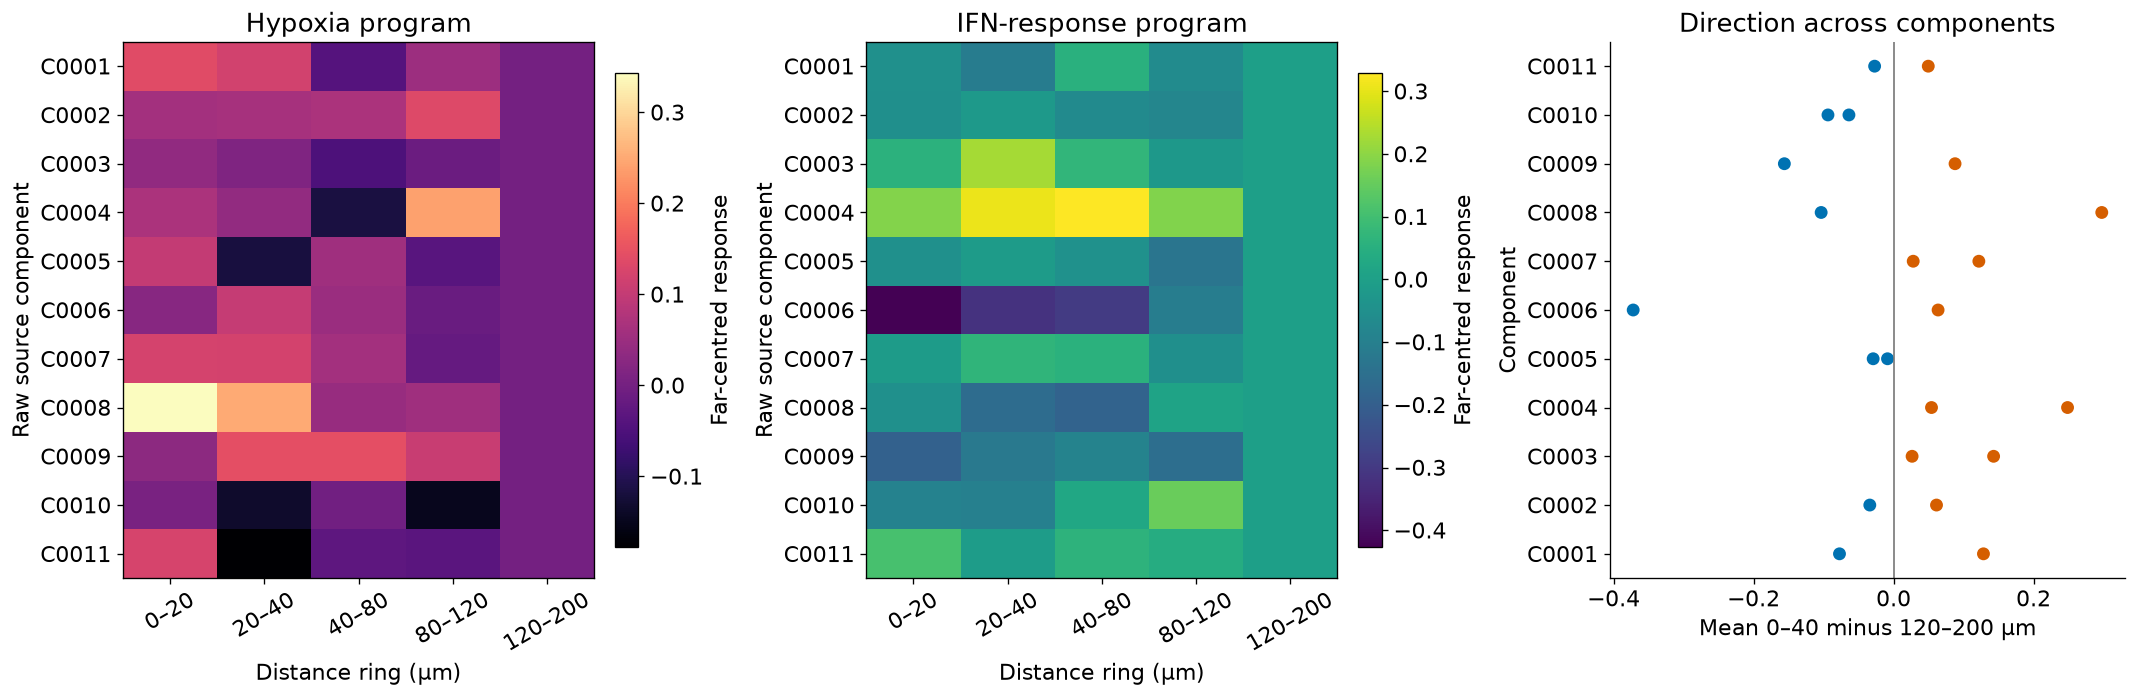

,components,mean_near_far,positive,negative
response_name,,,,
Hypoxia program,11,0.0674,8,3
IFN-response program,11,-0.0361,4,7


In [8]:
# All-component matrices and direction counts prevent one attractive map from dominating the conclusion.
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, response_name, cmap in zip(axes[:2], responses.values(), ["magma", "viridis"]):
    matrix = curves[curves.response_name.eq(response_name)].pivot(index="component_id", columns="ring_index", values="delta").reindex(columns=range(5))
    image = ax.imshow(matrix, aspect="auto", cmap=cmap)
    ax.set_xticks(range(5), ["0–20","20–40","40–80","80–120","120–200"], rotation=30)
    ax.set_yticks(range(len(matrix)), matrix.index); ax.set_title(response_name)
    ax.set_xlabel("Distance ring (µm)"); ax.set_ylabel("Raw source component")
    plt.colorbar(image, ax=ax, fraction=.046, pad=.04, label="Far-centred response")
summary = near_far.groupby("response_name").delta.agg(["count", "mean", lambda x: int((x>0).sum()), lambda x: int((x<0).sum())])
summary.columns = ["components", "mean_near_far", "positive", "negative"]
colors = ["#D55E00" if x > 0 else "#0072B2" for x in near_far.delta]
axes[2].scatter(near_far.delta, near_far.component_id, c=colors, s=45)
axes[2].axvline(0, color="#777", lw=1); axes[2].set_xlabel("Mean 0–40 minus 120–200 µm")
axes[2].set_ylabel("Component"); axes[2].set_title("Direction across components")
axes[2].spines[["top","right"]].set_visible(False)
fig.tight_layout(); plt.show()
display(summary.round(4))

In [9]:
h = near_far[near_far.response_name.eq("Hypoxia program")].delta
i = near_far[near_far.response_name.eq("IFN-response program")].delta
display(Markdown(f"""
### Interpretation

Starting from the raw matrices, Rab8a yields **{len(components.summary)}** spatial source components across
**{components.summary.section.nunique()}** sections. Hypoxia is higher in the 0–40 µm near field for
**{int((h>0).sum())}/{len(h)}** components, whereas IFN response is lower for **{int((i<0).sum())}/{len(i)}**.
The maps support a reproducible *local-state association*, not a formal propagation radius: `sgRab8a_1`
dominates the usable components, component crowding is substantial in subQ-4, and no adequate matched NTC
component series exists. The correct claim is therefore “Rab8a-marked malignant territories are often
hypoxic and IFN-low near their guide-positive cores,” with clone-level heterogeneity shown explicitly.
"""))


### Interpretation

Starting from the raw matrices, Rab8a yields **11** spatial source components across
**3** sections. Hypoxia is higher in the 0–40 µm near field for
**8/11** components, whereas IFN response is lower for **7/11**.
The maps support a reproducible *local-state association*, not a formal propagation radius: `sgRab8a_1`
dominates the usable components, component crowding is substantial in subQ-4, and no adequate matched NTC
component series exists. The correct claim is therefore “Rab8a-marked malignant territories are often
hypoxic and IFN-low near their guide-positive cores,” with clone-level heterogeneity shown explicitly.
